# 2.1 — Базовые модели (MLP, GRU, TCN)

**Папка 2 «Обучение моделей», подноутбук 1.** Для каждой базовой модели выполняется
**подбор гиперпараметров перебором по сетке (grid search)** с богатой историей (все метрики
по каждой конфигурации). Метрика отбора выбирается явно. Лучшая комбинация сохраняется в
`models/<имя>/hyperparams.json`, после чего финальное обучение **читает этот JSON** и обучает
модель «начисто» с отслеживанием метрик. Рисунки и таблицы — на английском.

## Окружение и данные

In [1]:
import sys
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    """Найти корень репозитория по наличию pyproject.toml вверх по дереву."""
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    return start


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

import numpy as np
import pandas as pd
from IPython.display import display

from liquefaction_ai.viz import register_theme

register_theme()

# Если True — все фигуры сохраняются в results/figs (.html и .png)
SAVE_FIGS = True
DATA_DIR = REPO_ROOT / "data" / "demo_run"
MODELS_DIR = REPO_ROOT / "models"

import torch

from liquefaction_ai import load_population_artifact, prepare_benchmark_dataset, train_model
from liquefaction_ai.training import grid_search, write_hyperparams, read_hyperparams, save_trained_model
from liquefaction_ai.evaluation import METRICS, english_metric_table, metrics_catalog, subsample_split
from liquefaction_ai.viz import grid_search_dashboard, training_dashboard, lines

population, config = load_population_artifact(DATA_DIR)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
benchmark = prepare_benchmark_dataset(population, config, device)
static_dim = benchmark["train"]["static"].shape[1]
prefix_dim = benchmark["train"]["prefix_summary"].shape[1]
seq_dim = benchmark["train"]["seq_in"].shape[-1]

# Grid search выполняется на компактной подвыборке (для ранжирования гиперпараметров).
gs_train = subsample_split(benchmark["train"], 2000, config.seed)
gs_val = subsample_split(benchmark["val"], 600, config.seed + 1)


def show_grid_dashboard(res, grid, score, metric_keys, fig_id):
    """Построить дашборд grid search: по Y — метрики, по X — текст конфигурации."""
    info = METRICS[score]
    labels = {k: f"{METRICS[k].name} ({METRICS[k].units})" for k in metric_keys}
    fmts = {k: METRICS[k].fmt for k in metric_keys}
    return grid_search_dashboard(res, metric_keys, list(grid.keys()), score,
                                 metric_labels=labels, metric_fmts=fmts,
                                 lower_is_better=info.lower_is_better, target=info.target,
                                 save=SAVE_FIGS, fig_id=fig_id)

print("device:", device, "| dims static/prefix/seq:", static_dim, prefix_dim, seq_dim)
from liquefaction_ai.models import (GRUBaseline, LSTMBaseline, RiskMLP, TCNBaseline,
                                    TransformerBaseline, FTTransformer, CatBoostBaseline,
                                    PINNBaseline, DeepStateBaseline, RealNVPFlow, NeuralSplineFlow)

device: cpu | dims static/prefix/seq: 34 6 5


## Каталог метрик

Все метрики качества определены с подробными описаниями в `liquefaction_ai.evaluation.metrics`
(`METRICS`) и импортируются в ноутбук. **Метрику отбора лучших гиперпараметров можно выбрать**
через переменную `SELECTION_METRIC` ниже.

In [2]:
display(metrics_catalog())

,Metric,Name,Units,Direction,Description
0,val_loss,Validation loss,–,lower is better,Mean validation value of the model's training ...
1,Traj_RMSE,Trajectory RMSE,–,lower is better,Root-mean-square error of the predicted pore-p...
2,Traj_MAE,Trajectory MAE,–,lower is better,Mean absolute error of the predicted PPR(N) tr...
3,Traj_MSE,Trajectory MSE,–,lower is better,Mean squared error of the predicted PPR(N) tra...
4,N_liq_MAE,MAE of N_liq,cycles,lower is better,Mean absolute error of the predicted number of...
5,AUROC,AUROC,–,higher is better,Area under the ROC curve for liquefaction-risk...
6,AUPRC,AUPRC,–,higher is better,Area under the precision–recall curve; classif...
7,Brier,Brier score,–,lower is better,Mean squared error of the predicted liquefacti...
8,ECE,Expected calibration error,–,lower is better,Average absolute gap between predicted confide...
9,Coverage_90,90% interval coverage,–,target ≈ 0.9,Empirical fraction of true PPR values that fal...


## Шаг 1. Grid search, история по всем метрикам и сохранение гиперпараметров

Для каждой модели задана своя метрика отбора `score` (можно менять). Дашборд показывает
все метрики по каждой конфигурации; лучшая по метрике отбора подсвечена.

[MLP-Risk] selection metric = Brier | best = {'hidden_dim': 128}


,hidden_dim,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,N_liq_n_observed,AUROC,AUPRC,Brier,...,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,N_CRR_test,N_CRR_objects,Produces CRR
0,128,0.1843,654.4545,1583.4709,1.2966,1.6927,118.0,0.9865,0.9979,0.0344,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0
1,64,0.3583,665.5643,1635.9192,1.5744,1.8585,118.0,0.9397,0.9830,0.0827,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0


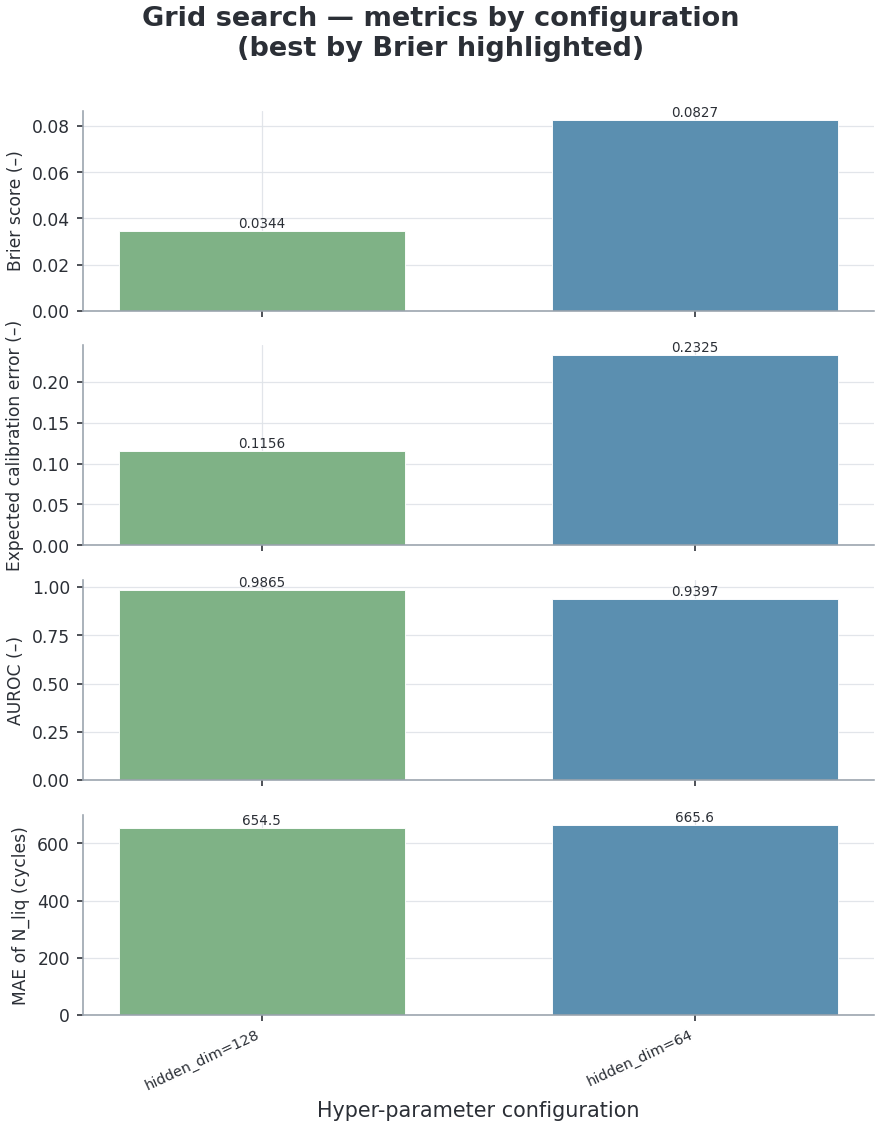

[GRU] selection metric = Traj_RMSE | best = {'hidden_dim': 96}


,hidden_dim,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,N_liq_n_observed,AUROC,AUPRC,Brier,...,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,N_CRR_test,N_CRR_objects,Produces CRR
0,96,0.1698,696.4315,1715.4200,1.7850,2.1774,118.0,0.9827,0.9972,0.1861,...,2.8098,1.0,3.3481,0.1167,0.8672,0.2707,NaN,0.0,0.0,0.0
1,64,0.2457,697.4326,1717.8907,1.8144,2.2353,118.0,0.9244,0.9892,0.2490,...,2.8942,1.0,3.4487,0.1167,0.8977,0.2791,NaN,0.0,0.0,0.0


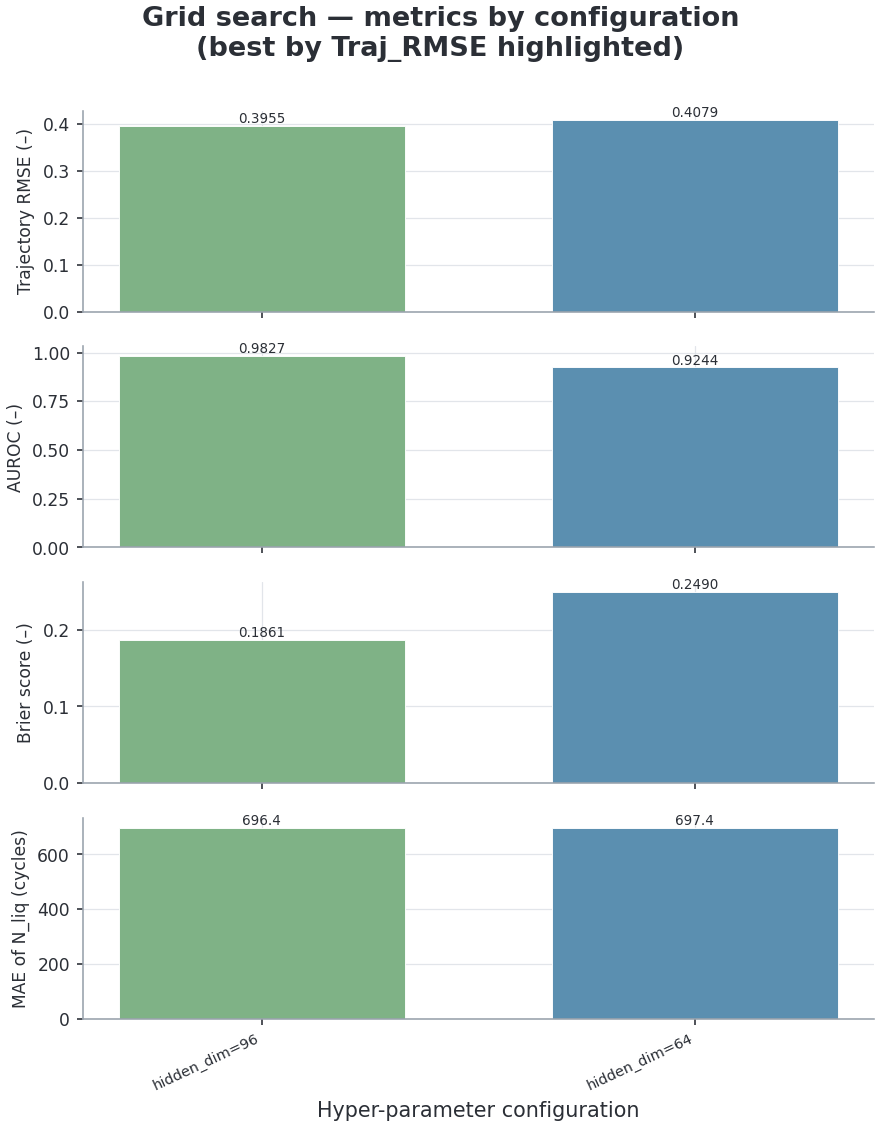

[TCN] selection metric = Traj_RMSE | best = {'hidden_dim': 96}


,hidden_dim,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,N_liq_n_observed,AUROC,AUPRC,Brier,...,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,N_CRR_test,N_CRR_objects,Produces CRR
0,96,0.2760,698.8716,1717.2976,1.8520,2.2455,118.0,0.9712,0.9947,0.2486,...,3.0396,1.0,3.6219,0.1167,0.9282,0.2801,NaN,0.0,0.0,0.0
1,64,0.3168,696.6695,1715.8109,1.7927,2.1897,118.0,0.9603,0.9921,0.2277,...,3.2347,1.0,3.8544,0.1167,0.9844,0.2933,NaN,0.0,0.0,0.0


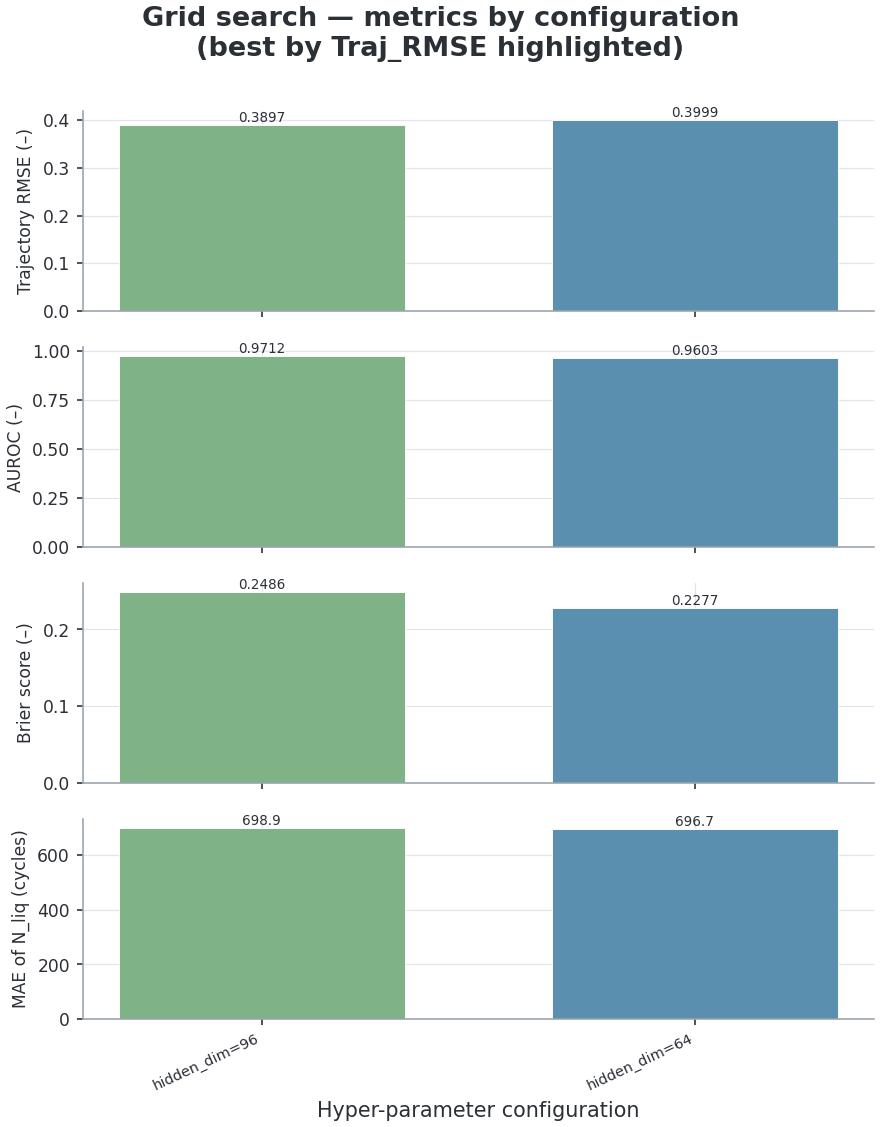

[LSTM] selection metric = Traj_RMSE | best = {'hidden_dim': 64}


,hidden_dim,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,N_liq_n_observed,AUROC,AUPRC,Brier,...,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,N_CRR_test,N_CRR_objects,Produces CRR
0,64,0.2056,692.8422,1713.5535,1.7012,2.1073,118.0,0.9821,0.9973,0.2153,...,2.9017,1.0,3.4576,0.1167,0.8829,0.268,NaN,0.0,0.0,0.0
1,96,0.3379,694.8386,1714.8407,1.7475,2.1491,118.0,0.9173,0.9885,0.2586,...,3.2584,1.0,3.8826,0.1167,0.9844,0.290,NaN,0.0,0.0,0.0


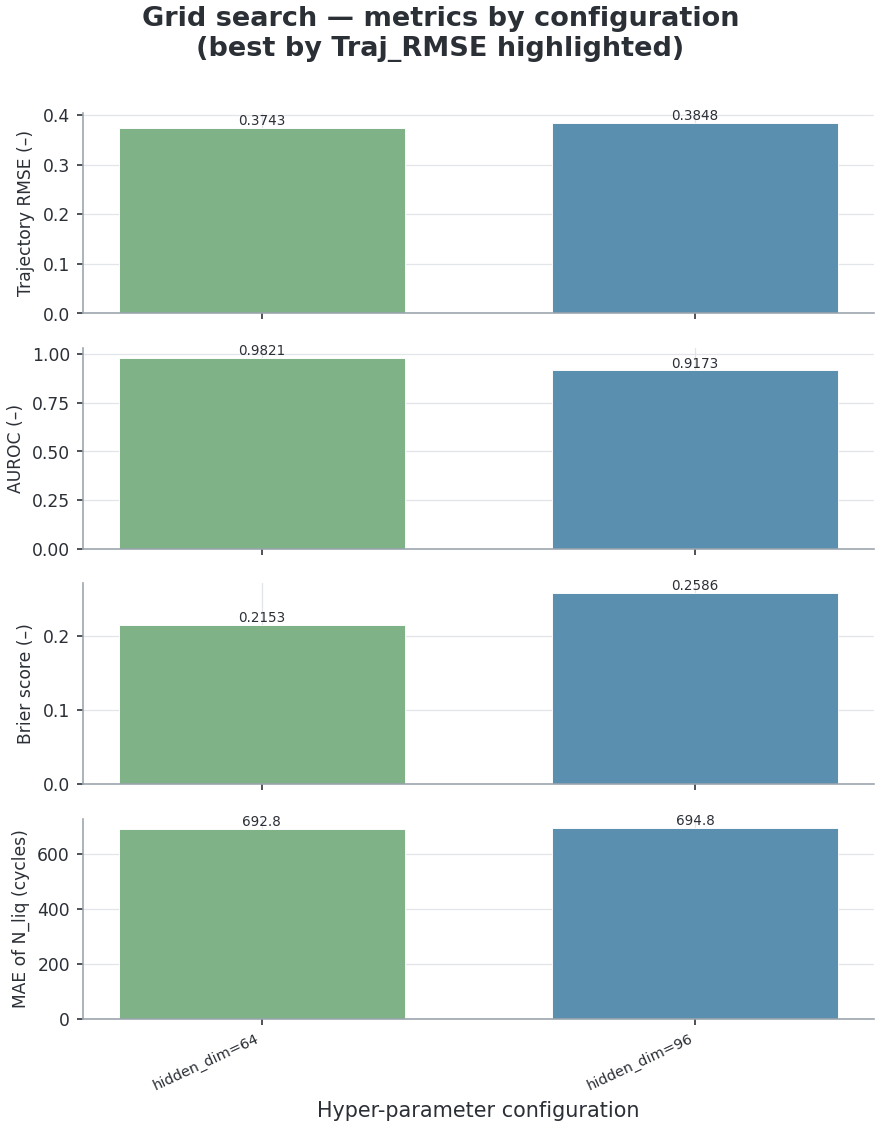

[Transformer] selection metric = Traj_RMSE | best = {'hidden_dim': 96}


,hidden_dim,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,N_liq_n_observed,AUROC,AUPRC,Brier,...,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,N_CRR_test,N_CRR_objects,Produces CRR
0,96,-1.1084,664.6136,1697.1146,1.3035,1.8112,118.0,0.9679,0.9938,0.1236,...,0.7718,0.9956,0.9196,0.0825,-0.3593,0.0857,NaN,0.0,0.0,0.0
1,64,-0.6518,682.8124,1708.6615,1.5067,2.0151,118.0,0.9801,0.9972,0.1622,...,1.1758,1.0000,1.4010,0.1164,0.0657,0.1340,NaN,0.0,0.0,0.0


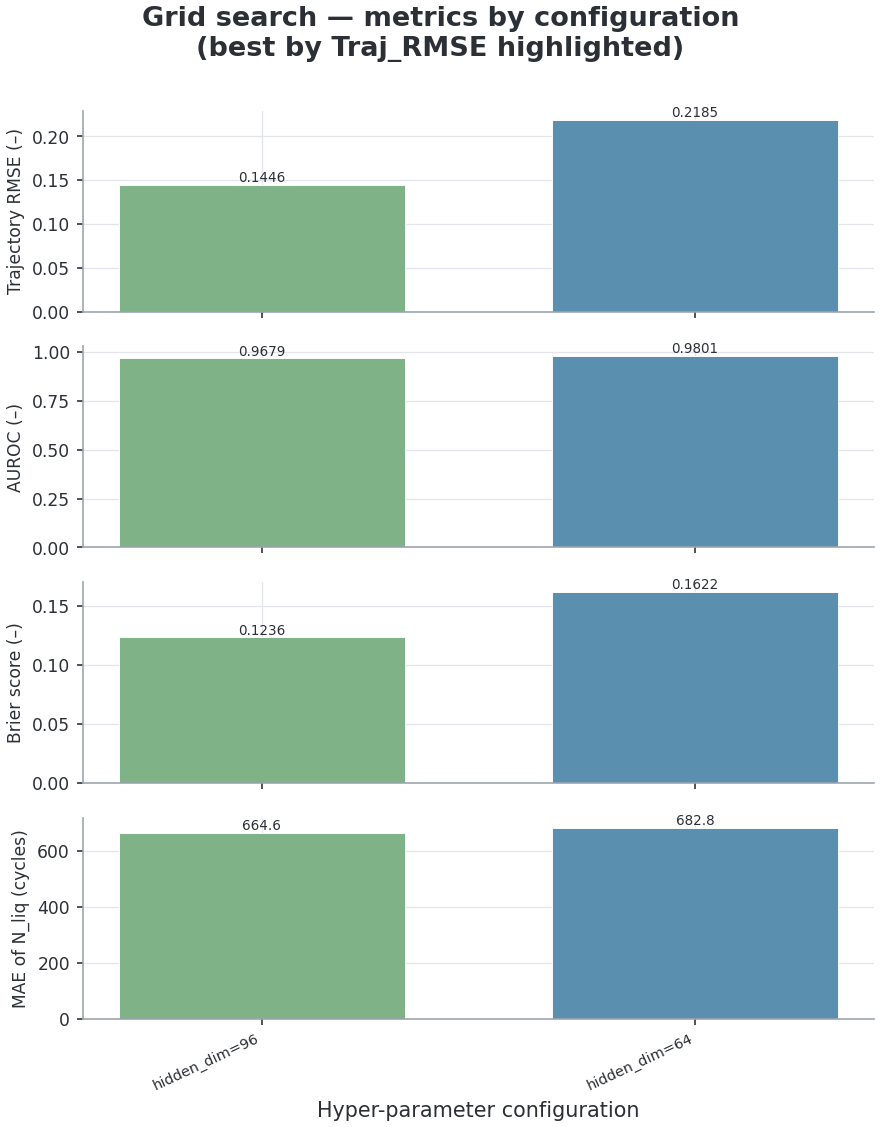

[FT-Transformer] selection metric = Brier | best = {'n_layers': 2}


,n_layers,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,N_liq_n_observed,AUROC,AUPRC,Brier,...,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,N_CRR_test,N_CRR_objects,Produces CRR
0,2,0.4150,653.8659,1662.9032,1.2259,1.6784,118.0,0.9776,0.9961,0.1101,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0
1,3,0.4159,653.1752,1660.1562,1.2230,1.6578,118.0,0.9737,0.9953,0.1106,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0


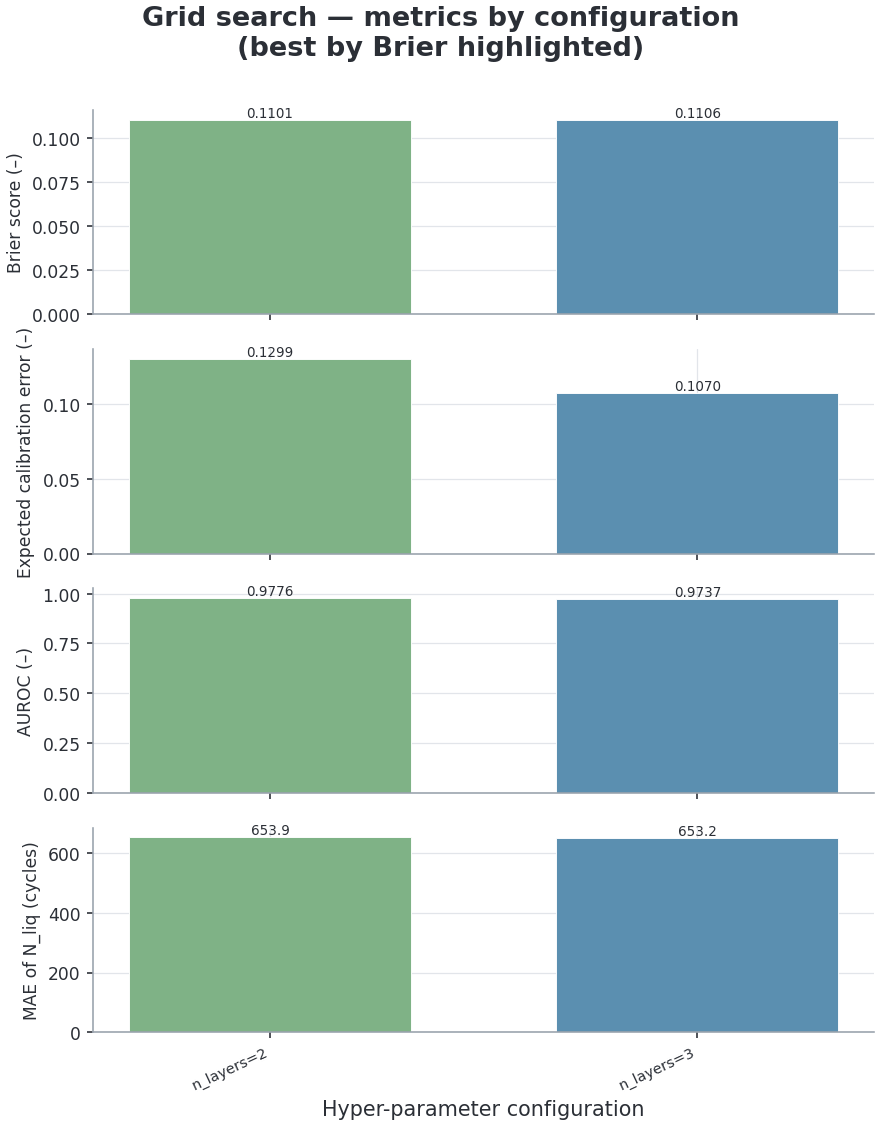

[PINN] selection metric = Traj_RMSE | best = {'hidden_dim': 96}


,hidden_dim,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,N_liq_n_observed,AUROC,AUPRC,Brier,...,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,N_CRR_test,N_CRR_objects,Produces CRR
0,96,-1.0152,642.8005,1667.0382,1.1122,1.5522,118.0,0.9808,0.9968,0.1461,...,0.7585,0.9988,0.9038,0.0766,-0.2794,0.0993,NaN,0.0,0.0,0.0
1,64,-0.0897,657.4634,1686.0679,1.2240,1.6736,118.0,0.9404,0.9907,0.3344,...,1.4783,1.0000,1.7615,0.0908,0.5041,0.2324,NaN,0.0,0.0,0.0


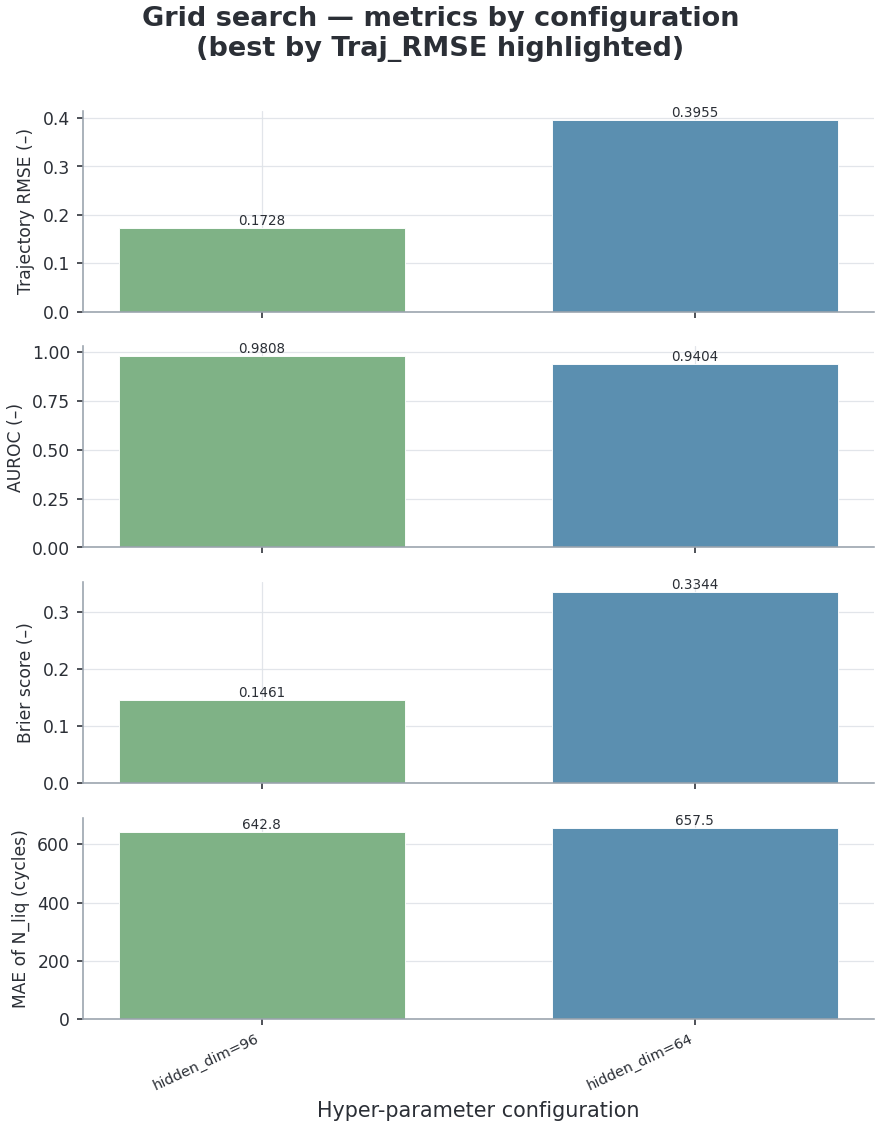

[DeepState] selection metric = Traj_RMSE | best = {'hidden_dim': 64}


,hidden_dim,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,N_liq_n_observed,AUROC,AUPRC,Brier,...,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,N_CRR_test,N_CRR_objects,Produces CRR
0,64,0.1688,700.6635,1718.0361,1.9049,2.2937,118.0,0.9481,0.9920,0.2448,...,2.8636,1.0,3.4121,0.1167,0.8232,0.2333,NaN,0.0,0.0,0.0
1,96,0.1346,693.2317,1714.5609,1.7107,2.1246,118.0,0.9712,0.9947,0.2337,...,2.7849,1.0,3.3183,0.1167,0.7988,0.2297,NaN,0.0,0.0,0.0


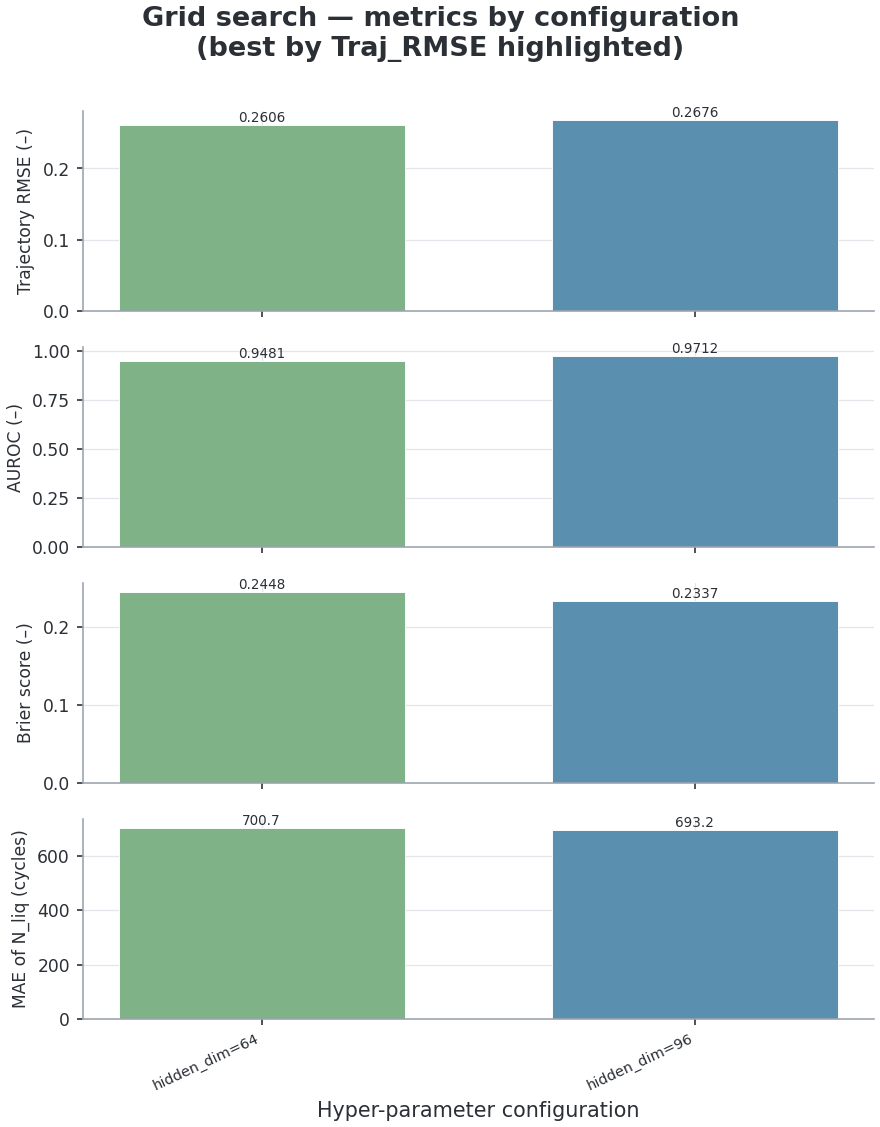

[RealNVP] selection metric = Traj_RMSE | best = {'n_layers': 6}


,n_layers,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,N_liq_n_observed,AUROC,AUPRC,Brier,...,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,N_CRR_test,N_CRR_objects,Produces CRR
0,6,6.1612,694.7573,1712.9626,1.7468,2.1332,118.0,0.5455,0.9140,0.2652,...,0.6957,0.5385,0.8290,0.4768,1.1496,0.2627,NaN,0.0,0.0,0.0
1,4,7.3151,689.3643,1713.1240,1.6298,2.0673,118.0,0.6064,0.9257,0.2453,...,0.6947,0.5330,0.8278,0.4797,1.1573,0.2638,NaN,0.0,0.0,0.0


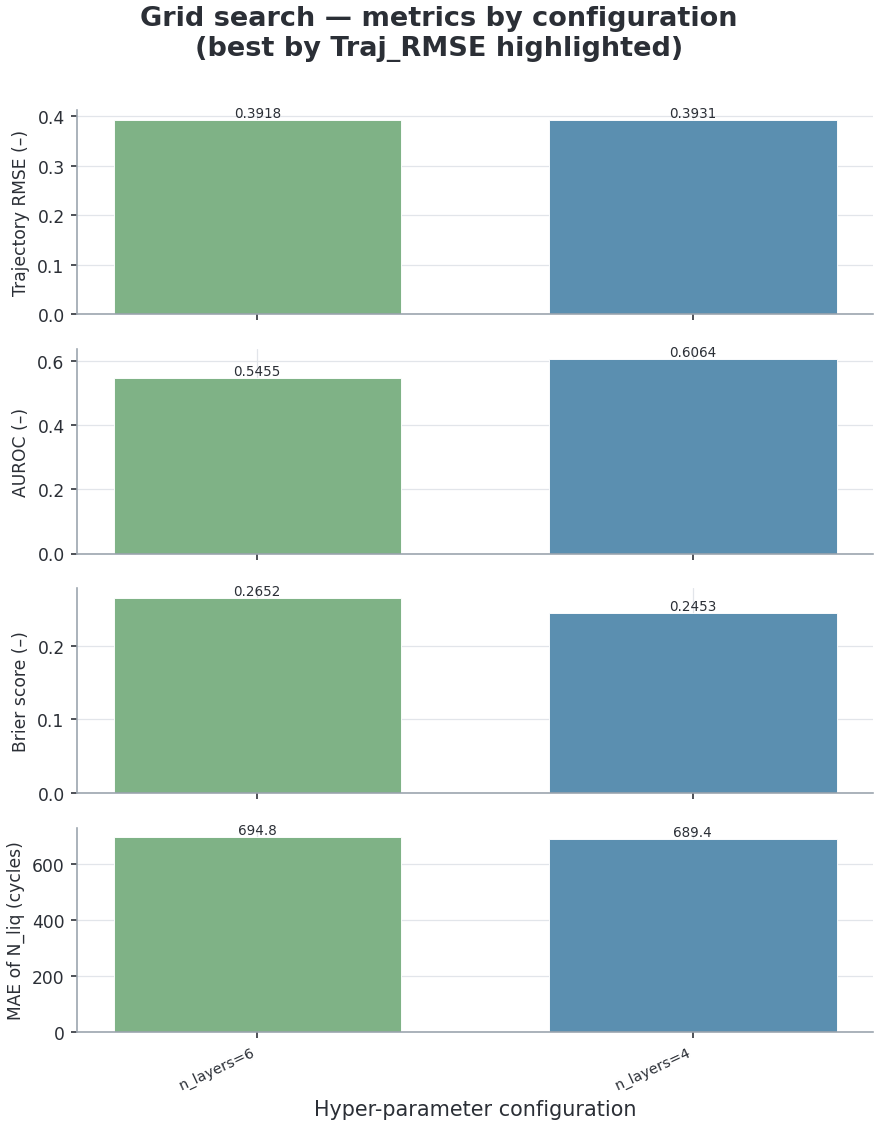

[Neural Spline Flow] selection metric = Traj_RMSE | best = {'n_layers': 5}


,n_layers,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,N_liq_n_observed,AUROC,AUPRC,Brier,...,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,N_CRR_test,N_CRR_objects,Produces CRR
0,5,16.2678,692.4370,1712.5148,1.7001,2.0947,118.0,0.8827,0.9614,0.2209,...,0.6797,0.5582,0.8099,0.4591,1.0355,0.2487,NaN,0.0,0.0,0.0
1,4,16.2368,692.4946,1714.0798,1.6988,2.1217,118.0,0.9929,0.9989,0.1866,...,0.6799,0.5521,0.8102,0.4607,1.0601,0.2512,NaN,0.0,0.0,0.0


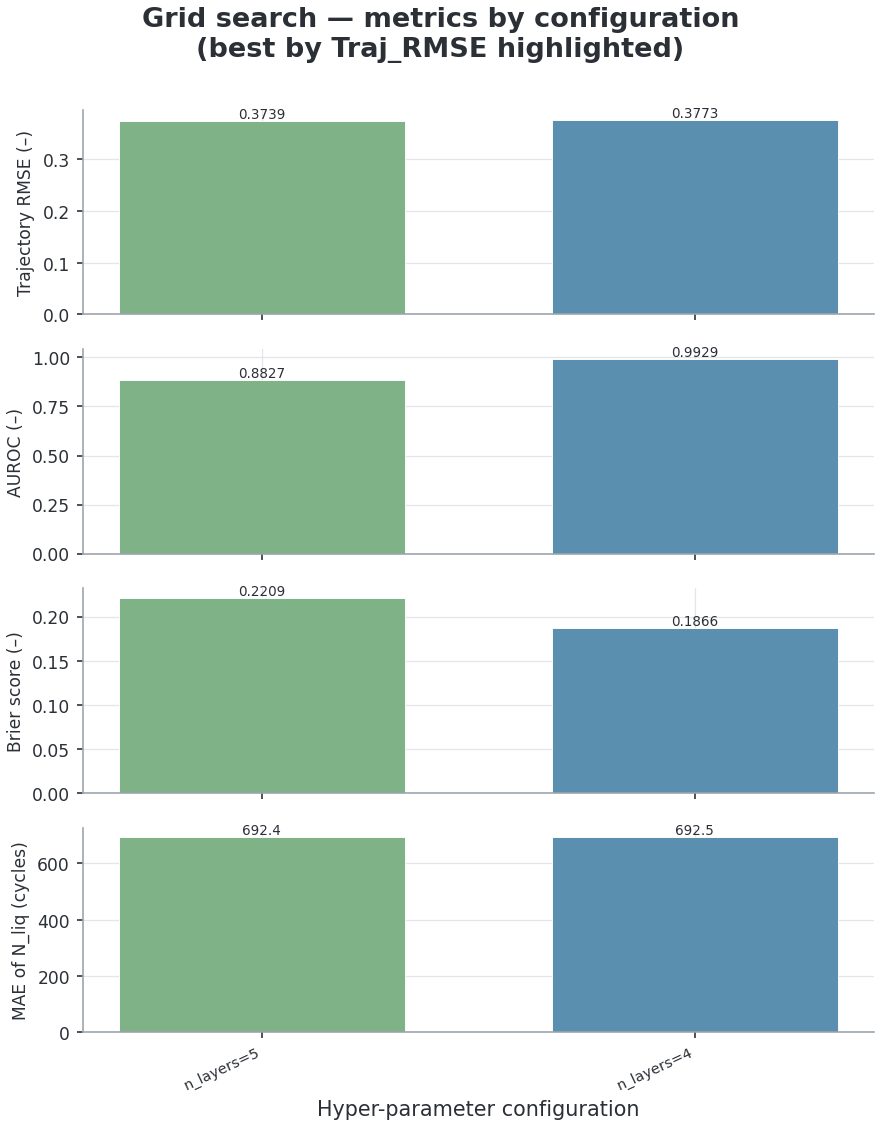

In [3]:
base_specs = {
    "mlp_risk": dict(display="MLP-Risk", cls=RiskMLP,
                     fixed=dict(static_dim=static_dim, prefix_dim=prefix_dim),
                     grid={"hidden_dim": [64, 128]}, score="Brier",
                     metrics=["Brier", "ECE", "AUROC", "N_liq_MAE"]),
    "gru": dict(display="GRU", cls=GRUBaseline,
                fixed=dict(static_dim=static_dim, seq_dim=seq_dim),
                grid={"hidden_dim": [64, 96]}, score="Traj_RMSE",
                metrics=["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE"]),
    "tcn": dict(display="TCN", cls=TCNBaseline,
                fixed=dict(static_dim=static_dim, seq_dim=seq_dim),
                grid={"hidden_dim": [64, 96]}, score="Traj_RMSE",
                metrics=["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE"]),
    "lstm": dict(display="LSTM", cls=LSTMBaseline,
                 fixed=dict(static_dim=static_dim, seq_dim=seq_dim),
                 grid={"hidden_dim": [64, 96]}, score="Traj_RMSE",
                 metrics=["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE"]),
    "transformer": dict(display="Transformer", cls=TransformerBaseline,
                 fixed=dict(static_dim=static_dim, seq_dim=seq_dim, seq_len=config.seq_len),
                 grid={"hidden_dim": [64, 96]}, score="Traj_RMSE",
                 metrics=["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE"]),
    "ft_transformer": dict(display="FT-Transformer", cls=FTTransformer,
                 fixed=dict(static_dim=static_dim, prefix_dim=prefix_dim),
                 grid={"n_layers": [2, 3]}, score="Brier",
                 metrics=["Brier", "ECE", "AUROC", "N_liq_MAE"]),
    "pinn": dict(display="PINN", cls=PINNBaseline,
                 fixed=dict(static_dim=static_dim, seq_dim=seq_dim),
                 grid={"hidden_dim": [64, 96]}, score="Traj_RMSE",
                 metrics=["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE"]),
    "deepstate": dict(display="DeepState", cls=DeepStateBaseline,
                 fixed=dict(static_dim=static_dim, seq_dim=seq_dim),
                 grid={"hidden_dim": [64, 96]}, score="Traj_RMSE",
                 metrics=["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE"]),
    "realnvp": dict(display="RealNVP", cls=RealNVPFlow,
                 fixed=dict(static_dim=static_dim, prefix_dim=prefix_dim, seq_len=config.seq_len),
                 grid={"n_layers": [4, 6]}, score="Traj_RMSE",
                 metrics=["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE"]),
    "nsf": dict(display="Neural Spline Flow", cls=NeuralSplineFlow,
                 fixed=dict(static_dim=static_dim, prefix_dim=prefix_dim, seq_len=config.seq_len),
                 grid={"n_layers": [4, 5]}, score="Traj_RMSE",
                 metrics=["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE"]),
}

for name, spec in base_specs.items():
    cls, fixed, grid, score = spec["cls"], spec["fixed"], spec["grid"], spec["score"]
    res, best = grid_search(lambda p, cls=cls, fixed=fixed: cls(**fixed, **p),
                            grid, gs_train, gs_val, config, device, search_epochs=1, score_metric=score)
    write_hyperparams(MODELS_DIR, name, {"model_type": cls.__name__, "display_name": spec["display"],
                      "model_kwargs": {**fixed, **best}, "search": {"grid": grid, "score_metric": score, "best": best}})
    print(f"[{spec['display']}] selection metric = {score} | best = {best}")
    display(english_metric_table(res).round(4))
    show_grid_dashboard(res, grid, score, spec["metrics"], f"2_1_grid_search_{name}").show()

## Шаг 2. Финальное обучение по сохранённым гиперпараметрам

In [4]:
# Реестр классов всех baseline (имя класса -> класс) и число эпох по семействам
CLS = {RiskMLP.__name__: RiskMLP, GRUBaseline.__name__: GRUBaseline, TCNBaseline.__name__: TCNBaseline,
       LSTMBaseline.__name__: LSTMBaseline, TransformerBaseline.__name__: TransformerBaseline,
       FTTransformer.__name__: FTTransformer, PINNBaseline.__name__: PINNBaseline,
       DeepStateBaseline.__name__: DeepStateBaseline, RealNVPFlow.__name__: RealNVPFlow,
       NeuralSplineFlow.__name__: NeuralSplineFlow}
# PINN — физически-структурированная (больше эпох); остальные baseline — config.baseline_epochs
epoch_map = {name: (config.physics_epochs if name == "pinn" else config.baseline_epochs) for name in base_specs}
histories = {}
for name in base_specs:
    hp = read_hyperparams(MODELS_DIR, name)
    model = CLS[hp["model_type"]](**hp["model_kwargs"]).to(device)
    epochs = epoch_map[name]
    model, history = train_model(model, benchmark["train"], benchmark["val"], epochs=epochs,
                                 model_name=hp["display_name"], config=config, device=device, track_metrics=True)
    save_trained_model(model, MODELS_DIR, name, {**hp, "epochs": epochs, "learning_rate": config.learning_rate,
                       "weight_decay": config.weight_decay, "batch_size": config.batch_size, "seed": config.seed}, history)
    histories[hp["display_name"]] = history
    print("saved:", MODELS_DIR / name)

[MLP-Risk] эпоха 01 | обучение=0.6933 | валидация=0.1843 | val_AUROC=0.987


[MLP-Risk] эпоха 02 | обучение=0.2792 | валидация=0.0888 | val_AUROC=0.985


[MLP-Risk] эпоха 03 | обучение=0.1552 | валидация=0.0897 | val_AUROC=0.987


[MLP-Risk] эпоха 04 | обучение=0.1155 | валидация=0.0830 | val_AUROC=0.991


saved: /Users/nikita/Desktop/projects/liquefaction-ai/models/mlp_risk


...

[Neural Spline Flow] эпоха 01 | обучение=11.4660 | валидация=16.2678 | val_AUROC=0.883 | val_RMSE=0.3739


[Neural Spline Flow] эпоха 02 | обучение=11.6549 | валидация=15.9744 | val_AUROC=0.965 | val_RMSE=0.3459


[Neural Spline Flow] эпоха 03 | обучение=11.1883 | валидация=15.7616 | val_AUROC=0.980 | val_RMSE=0.3173


[Neural Spline Flow] эпоха 04 | обучение=11.4048 | валидация=15.6510 | val_AUROC=0.981 | val_RMSE=0.2926


saved: /Users/nikita/Desktop/projects/liquefaction-ai/models/nsf


## Кривые обучения с метриками

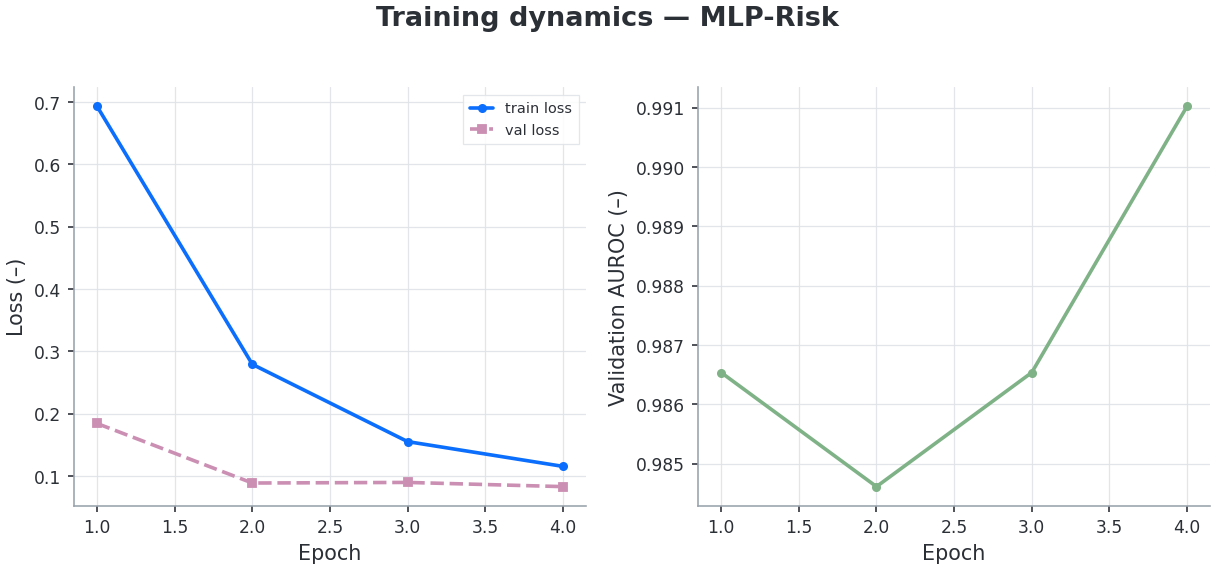

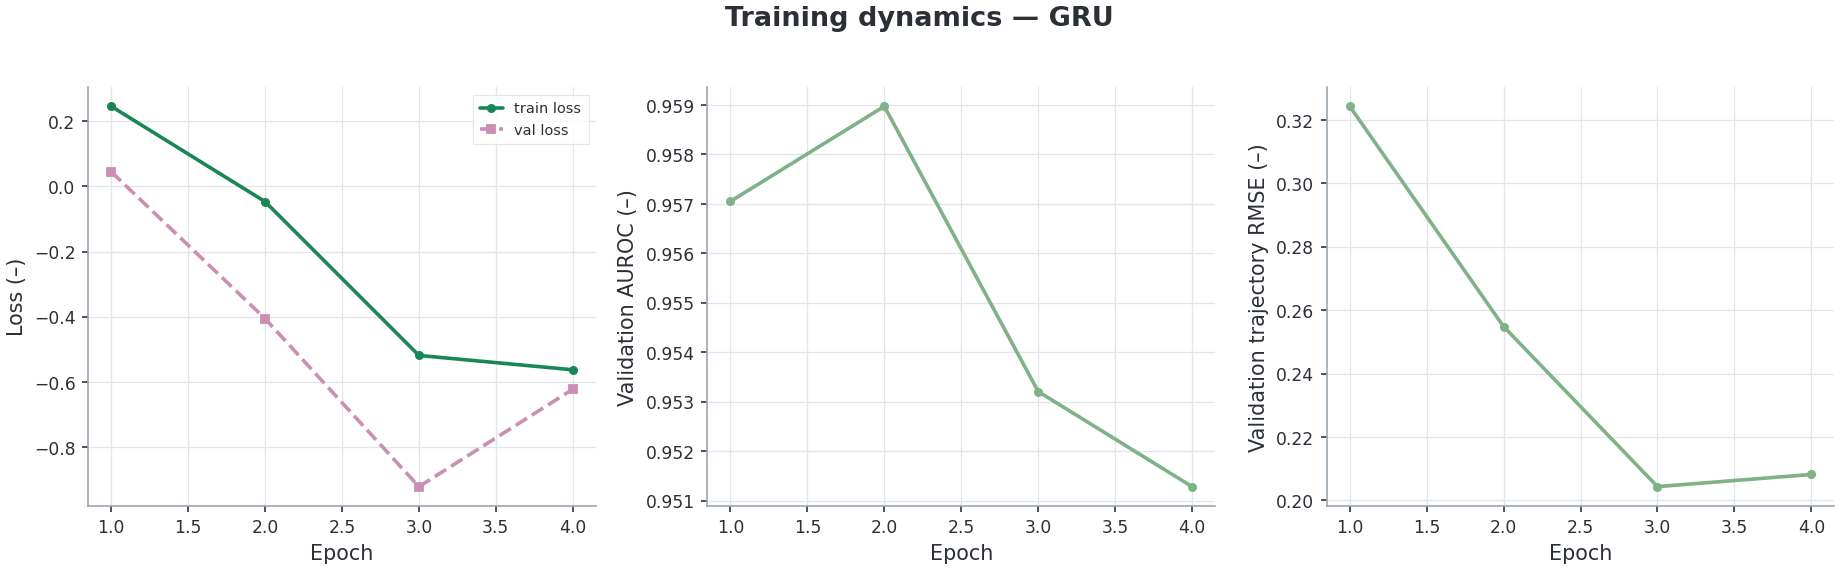

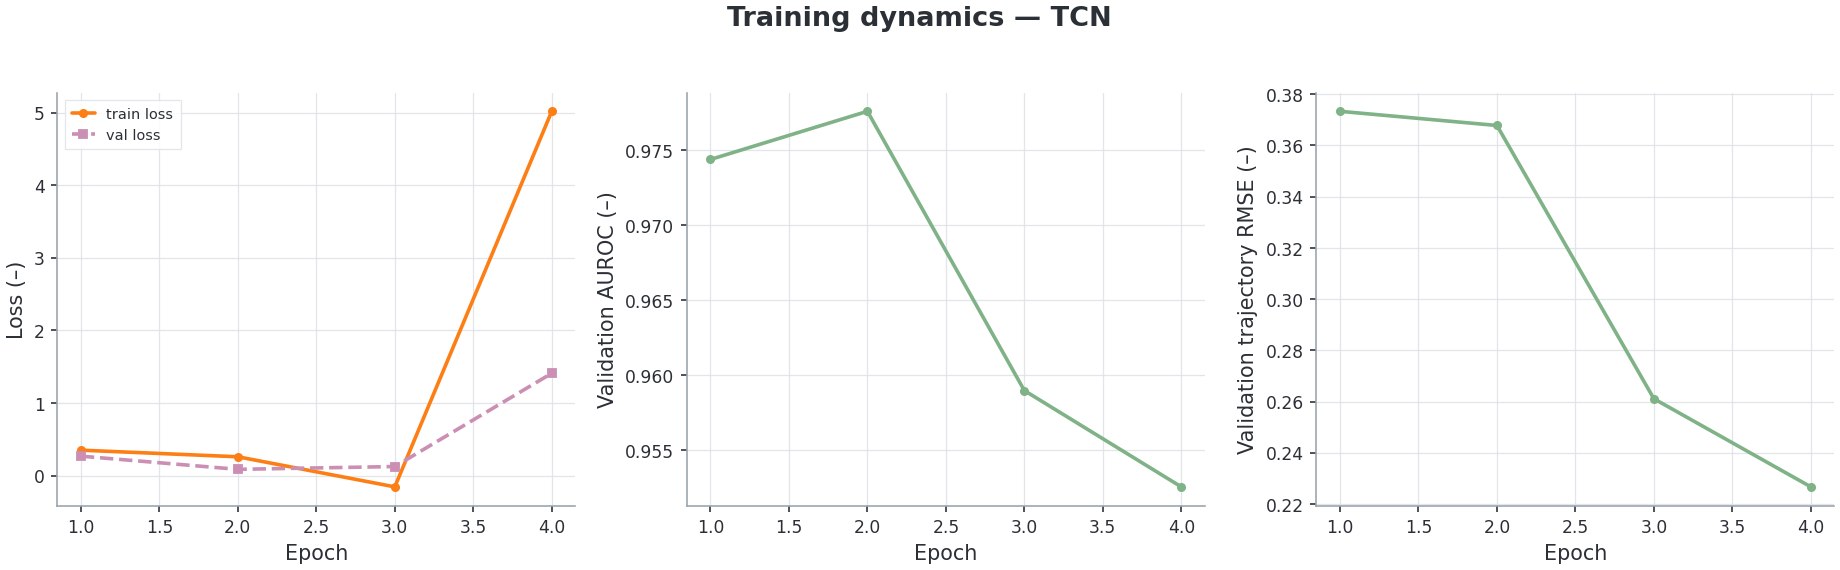

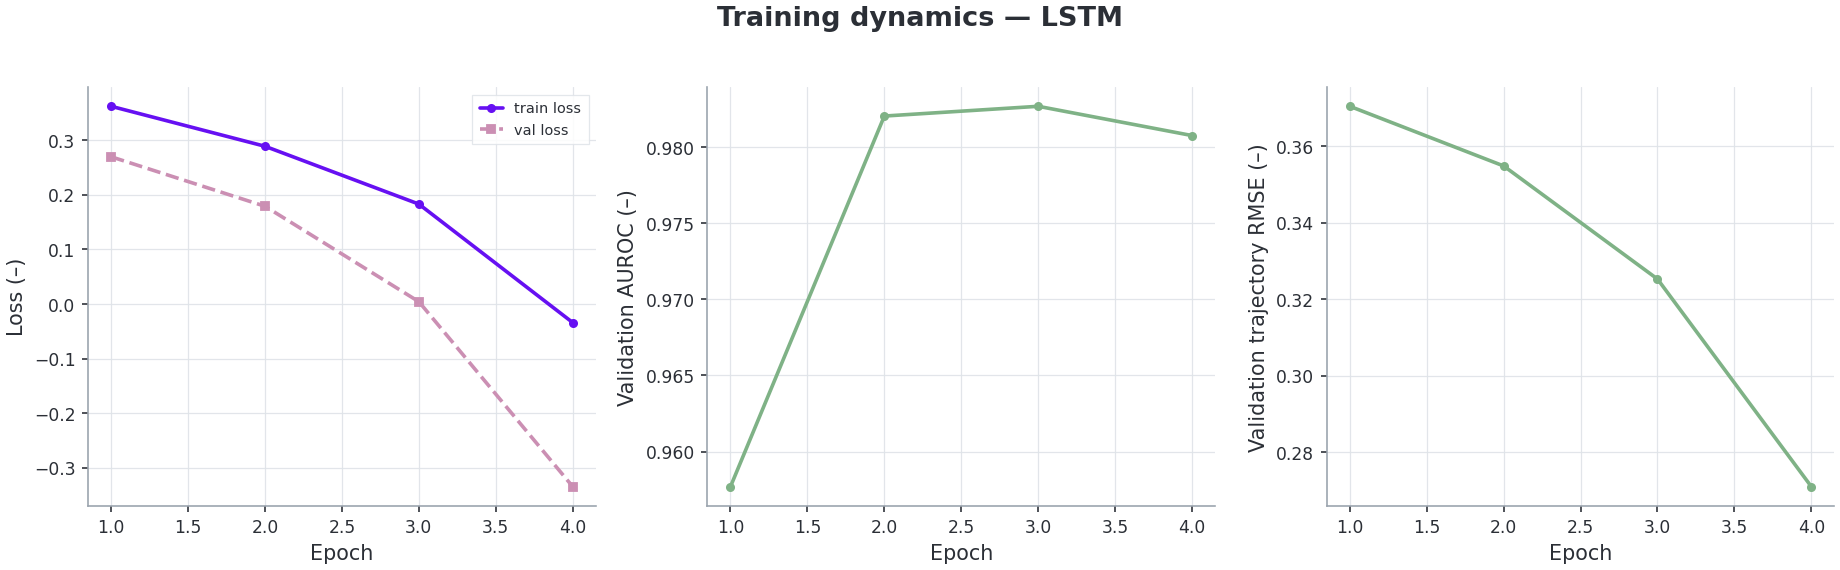

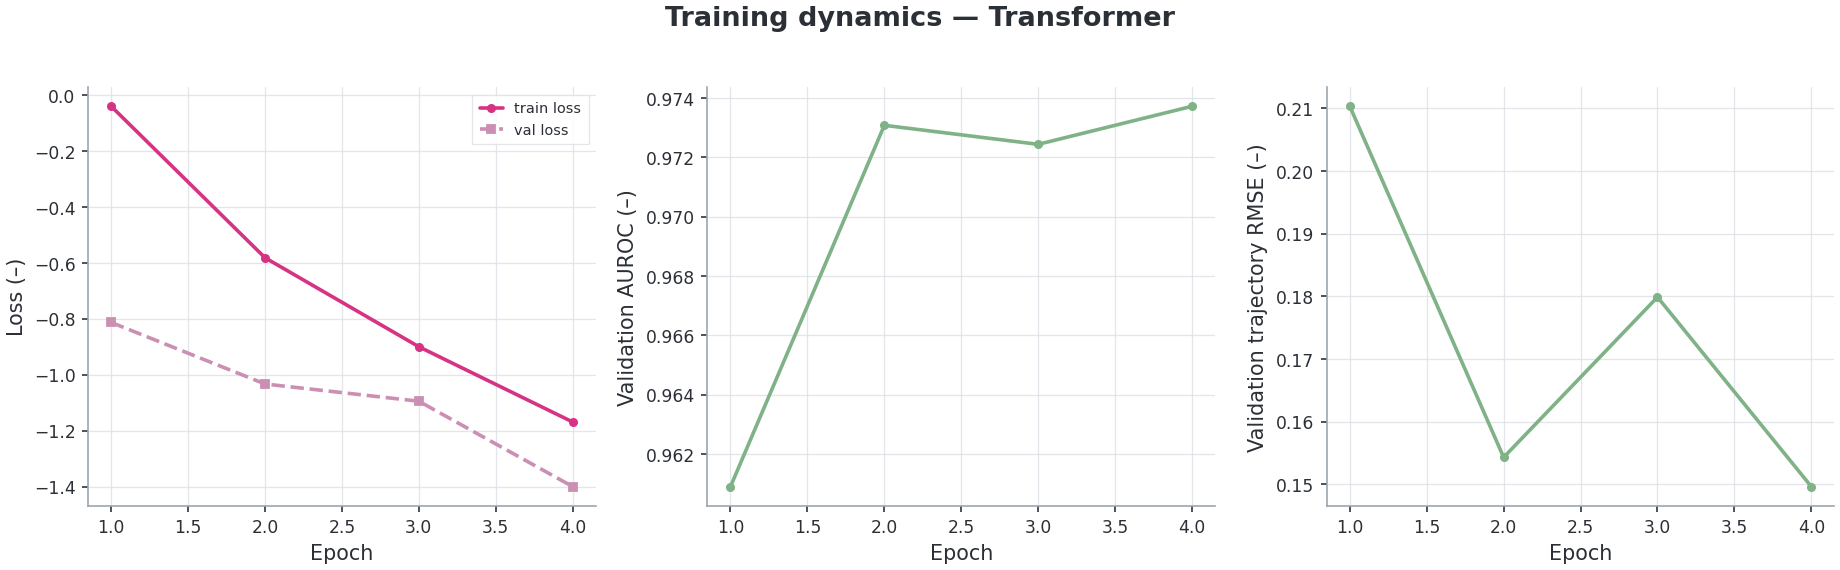

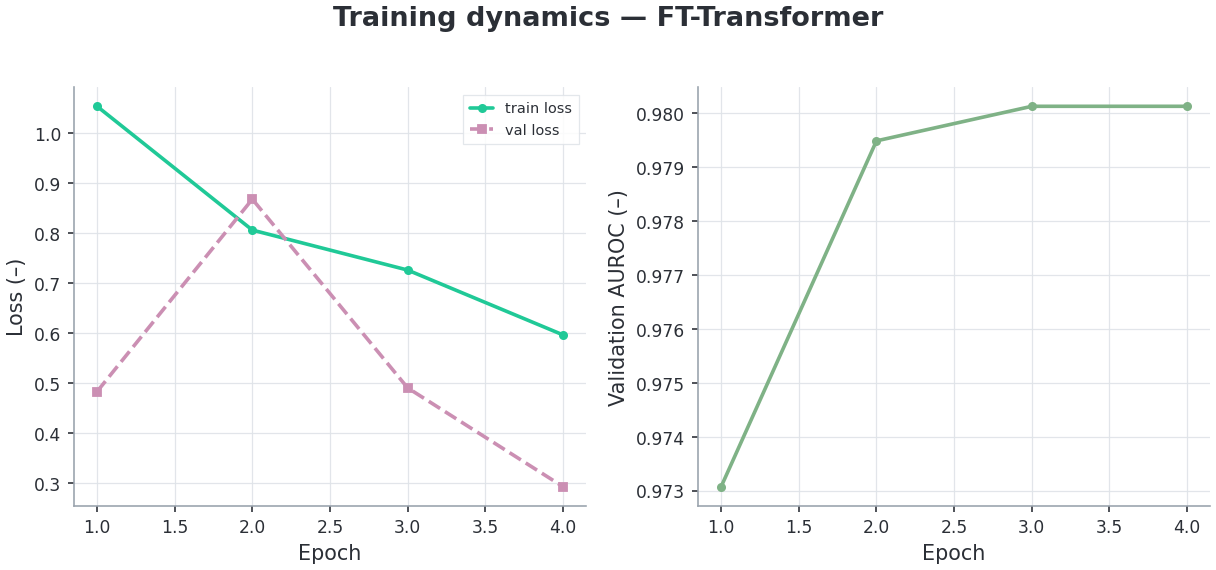

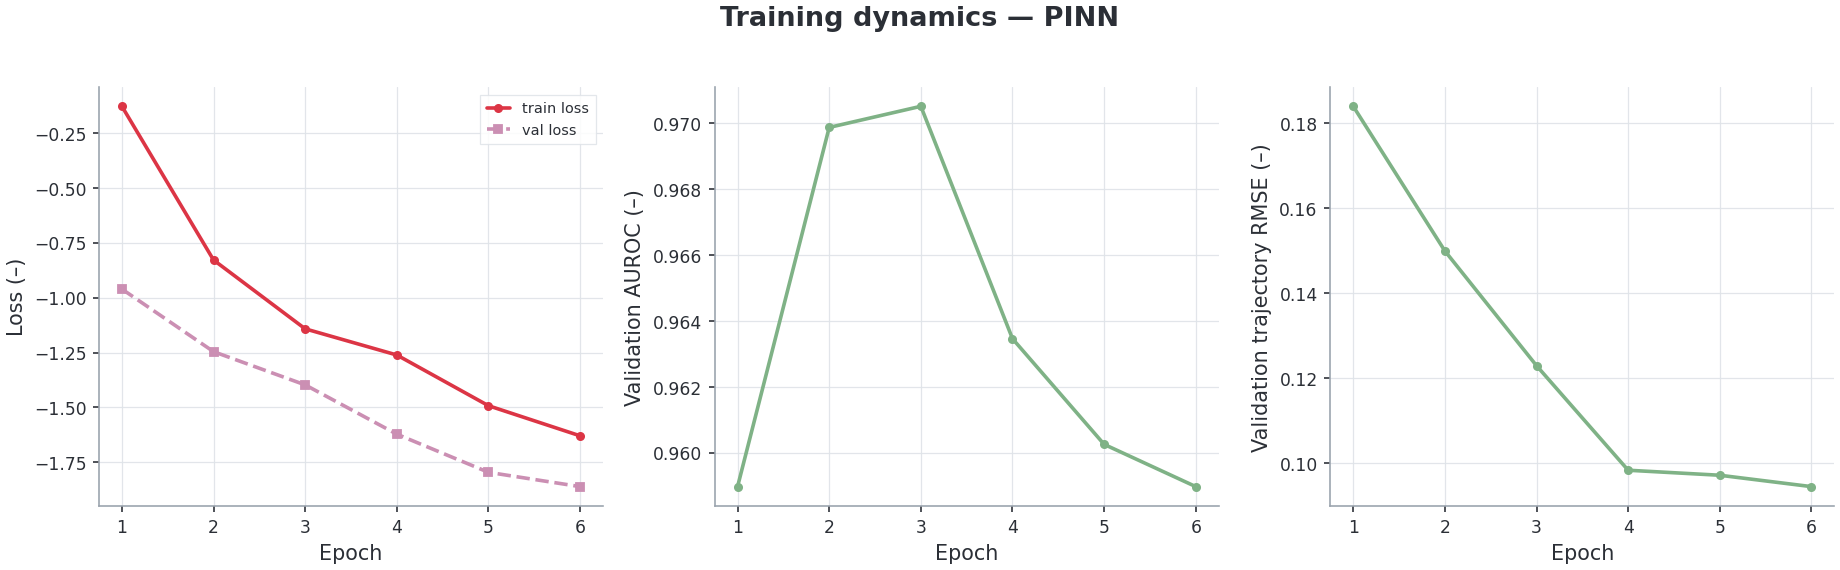

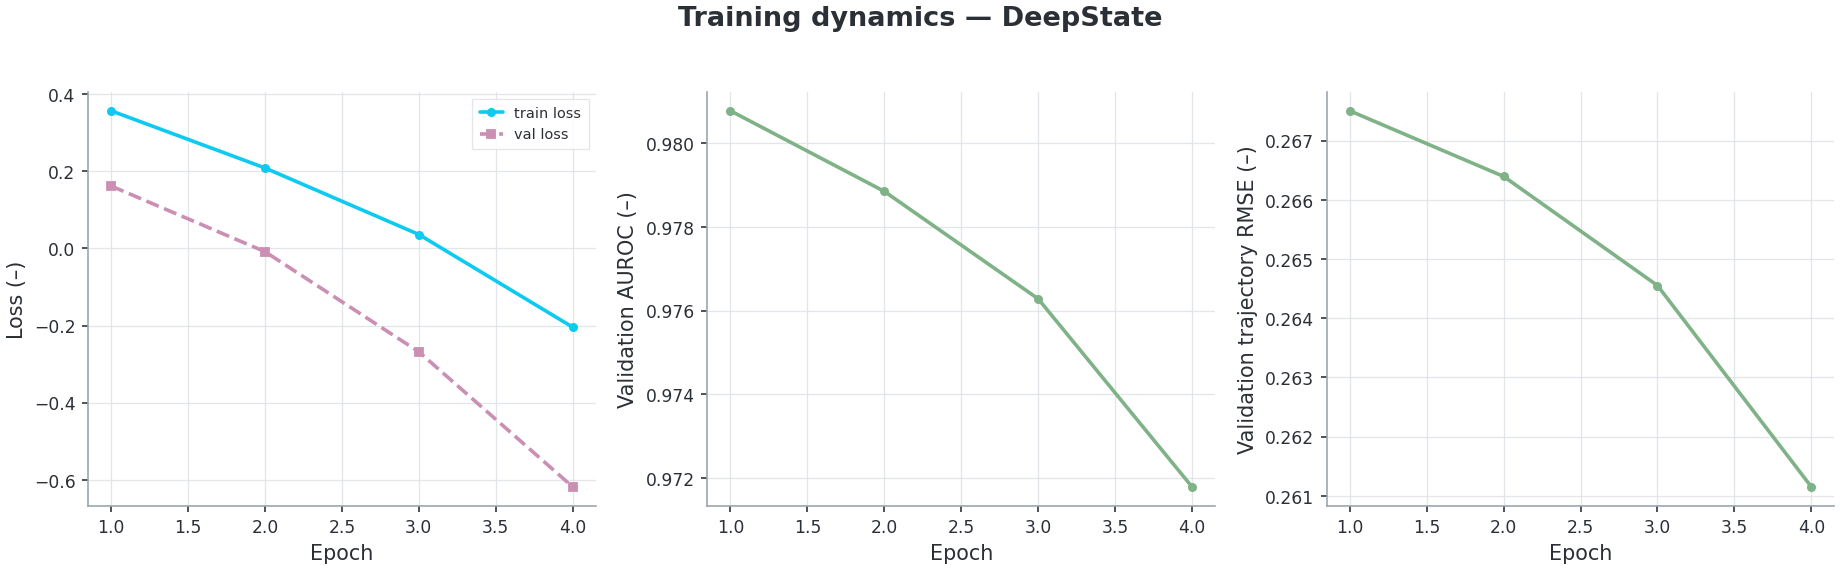

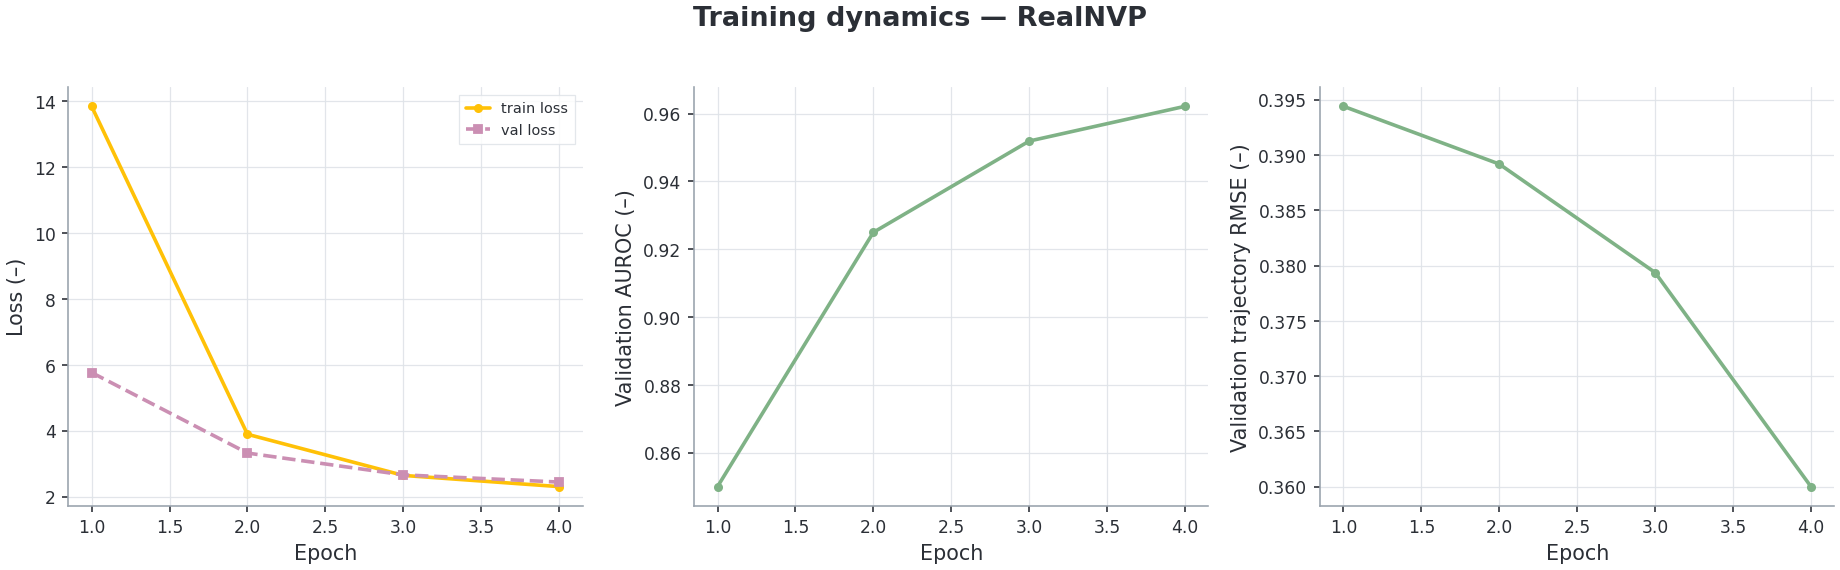

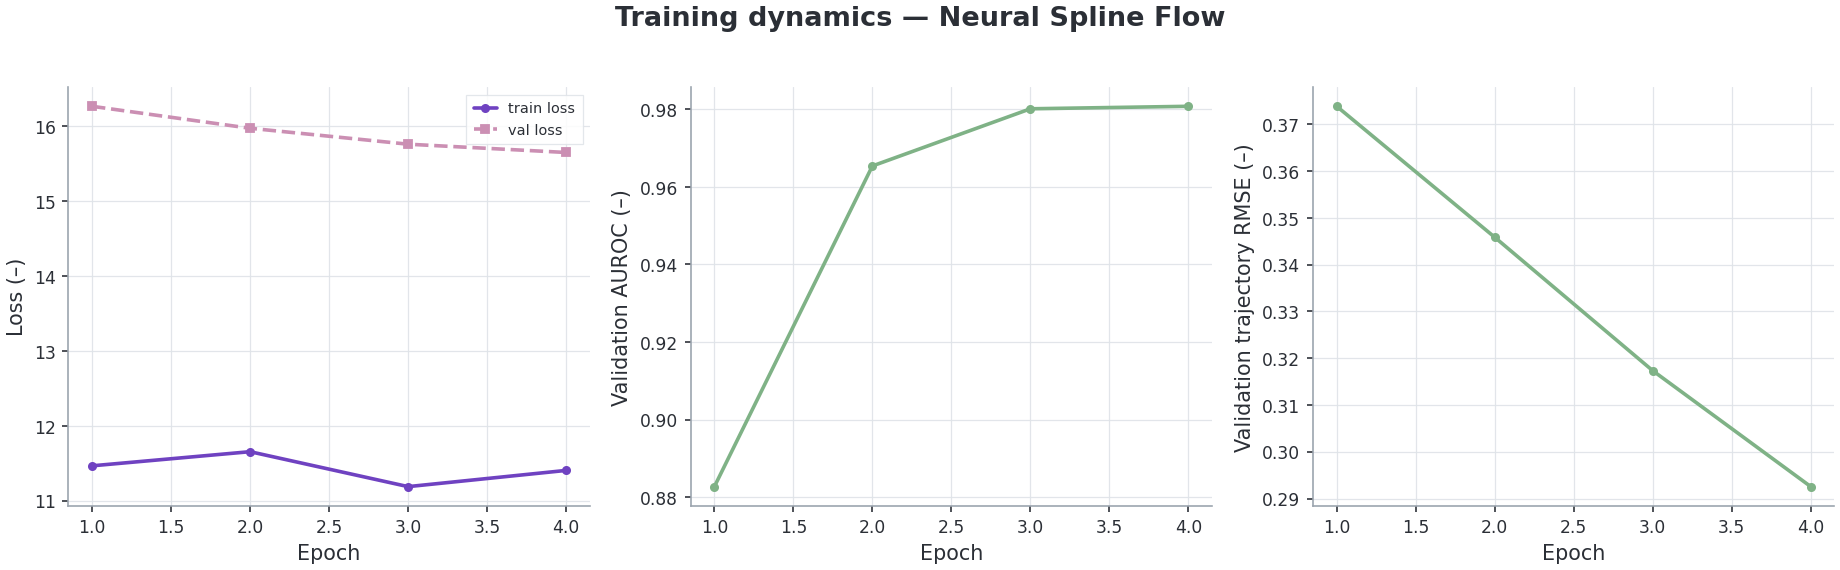

In [5]:
palette = ["#0b6efd", "#198754", "#fd7e14", "#6610f2", "#d63384", "#20c997", "#dc3545", "#0dcaf0", "#ffc107", "#6f42c1"]
colors = {disp: palette[i % len(palette)] for i, disp in enumerate(histories)}
for disp, hist in histories.items():
    training_dashboard(hist, title=f"Training dynamics — {disp}", model_color=colors[disp],
                       save=SAVE_FIGS, fig_id=f"2_1_training_{disp.lower().replace('-', '_')}").show()

## Итог

Базовые модели подобраны grid search (с выбором метрики) и обучены. Дальше — **2.2 DPI-Flow**.

In [6]:
# --- CatBoost (табличный градиентный бустинг) ---
# Не нейросеть, поэтому обучается своим .fit (не train_model) и сохраняется нативно.
cb = CatBoostBaseline(static_dim, prefix_dim).fit(benchmark["train"], benchmark["val"])
cb.save(MODELS_DIR, "catboost")
write_hyperparams(MODELS_DIR, "catboost", {"model_type": "CatBoostBaseline", "display_name": "CatBoost",
                  "model_kwargs": dict(static_dim=static_dim, prefix_dim=prefix_dim)})
print("saved:", MODELS_DIR / "catboost")

saved: /Users/nikita/Desktop/projects/liquefaction-ai/models/catboost
